## Importing Libraries


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 140590 files belonging to 38 classes.


### Validation Image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 35144 files belonging to 38 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[171.25 162.25 167.25]
   [180.25 171.25 176.25]
   [175.25 166.25 171.25]
   ...
   [178.5  171.5  178.5 ]
   [175.25 168.25 175.25]
   [180.25 173.25 180.25]]

  [[170.25 161.25 166.25]
   [181.25 172.25 177.25]
   [183.25 174.25 179.25]
   ...
   [180.   173.   180.  ]
   [174.75 167.75 174.75]
   [177.25 170.25 177.25]]

  [[167.25 158.25 163.25]
   [169.   160.   165.  ]
   [176.75 167.75 172.75]
   ...
   [170.   163.   170.  ]
   [180.   173.   180.  ]
   [182.5  175.5  182.5 ]]

  ...

  [[111.5   99.5   99.5 ]
   [104.    92.    92.  ]
   [102.75  90.75  90.75]
   ...
   [107.25  95.25  99.25]
   [106.25  94.25  98.25]
   [104.75  92.75  96.75]]

  [[100.    88.    88.  ]
   [106.25  94.25  94.25]
   [107.5   95.5   95.5 ]
   ...
   [103.5   91.5   95.5 ]
   [109.    97.   101.  ]
   [102.5   90.5   94.5 ]]

  [[116.75 104.75 104.75]
   [ 95.25  83.25  83.25]
   [ 99.75  87.75  87.75]
   ...
   [ 96.5   84.5   88.5 ]
   [103.75  91.75  95.75]
   [110.75  98.75 10

## Building Model

In [6]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [7]:
model =Sequential()

1.overshooting
2.choose small learning default rate as 0.001 to 0.0001
3.add more neuron to avoid underfitting
4.

### building Covolution layer

In [9]:
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPool2D(2,2))

In [10]:
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))

In [11]:
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))

In [12]:
model.add(Dropout(0.25))

In [13]:
model.add(Flatten())

In [14]:
model.add(Dense(128, activation='relu'))

In [15]:
model.add(Dropout(0.3))

### Output Layers

In [16]:
model.add(Dense(38, activation='softmax'))

## Compiling model

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 697,350 (2.66 MB)

 Trainable params: 697,350 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

## Model Traning

In [19]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 881s 199ms/step - accuracy: 0.4967 - loss: 1.8551 - val_accuracy: 0.8433 - val_loss: 0.5363
Epoch 2/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 870s 198ms/step - accuracy: 0.8219 - loss: 0.5864 - val_accuracy: 0.9060 - val_loss: 0.3106
Epoch 3/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 853s 194ms/step - accuracy: 0.8908 - loss: 0.3465 - val_accuracy: 0.9239 - val_loss: 0.2361
Epoch 4/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 857s 193ms/step - accuracy: 0.9243 - loss: 0.2361 - val_accuracy: 0.9500 - val_loss: 0.1619
Epoch 5/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 875s 196ms/step - accuracy: 0.9422 - loss: 0.1749 - val_accuracy: 0.9542 - val_loss: 0.1424
Epoch 6/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 863s 196ms/step - accuracy: 0.9548 - loss: 0.1381 - val_accuracy: 0.9597 - val_loss: 0.1247
Epoch 7/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 864s 197ms/step - accuracy: 0.9612 - loss: 0.1153 - val_accuracy: 0.9579 - val_loss: 0.1318
Epoch 8/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 886s 202ms/step - ac

## Model Evaluation

In [20]:
#ModelEvaluation on training set

train_loss,train_acc = model.evaluate(training_set)

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 648s 147ms/step - accuracy: 0.9956 - loss: 0.0164


In [21]:
print(train_loss,train_acc)

0.01644769124686718 0.9956042170524597


In [22]:
#ModelEvaluation on validation set
val_loss,val_acc = model.evaluate(validation_set)

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 160s 146ms/step - accuracy: 0.9603 - loss: 0.1317


In [23]:
print(val_loss,val_acc)

0.13169044256210327 0.9603345990180969


## Saving Model

In [24]:
model.save("trained_model.keras")

In [25]:
training_history.history

{'accuracy': [0.4966925084590912,
  0.8218792080879211,
  0.890831470489502,
  0.9242691397666931,
  0.9421651363372803,
  0.9548261165618896,
  0.9612419009208679,
  0.9664983153343201,
  0.9704246520996094,
  0.9733480215072632],
 'loss': [1.8551156520843506,
  0.5863654017448425,
  0.34651675820350647,
  0.2360566407442093,
  0.1748833954334259,
  0.13807524740695953,
  0.11530278623104095,
  0.09930165857076645,
  0.08768297731876373,
  0.07995705306529999],
 'val_accuracy': [0.8433303236961365,
  0.9059867858886719,
  0.9239130616188049,
  0.9500341415405273,
  0.954245388507843,
  0.9597086310386658,
  0.9578875303268433,
  0.9645458459854126,
  0.9636922478675842,
  0.9603345990180969],
 'val_loss': [0.5362546443939209,
  0.31063440442085266,
  0.23614194989204407,
  0.1618977040052414,
  0.1423943042755127,
  0.12470243871212006,
  0.13179056346416473,
  0.11154009401798248,
  0.11410396546125412,
  0.13169050216674805]}

In [26]:
#record history in json file
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

## Accuracy Visualization

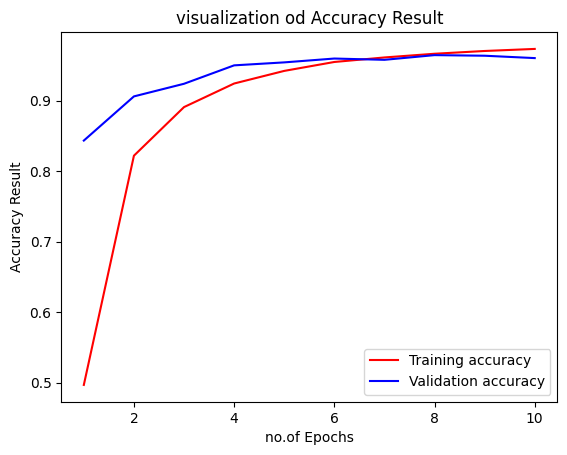

In [27]:
epochs = [i for i in range (1,11)]
plt.plot(epochs,training_history.history['accuracy'],color ='red',label='Training accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color ='blue',label='Validation accuracy')
plt.xlabel("no.of Epochs")
plt.ylabel("Accuracy Result")
plt.title("visualization od Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [28]:
class_name  = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [30]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 35144 files belonging to 38 classes.


In [31]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 64s 58ms/step


(array([[6.4641345e-01, 4.9340415e-06, 4.1425149e-10, ..., 9.3406305e-13,
         9.4178376e-10, 2.4565833e-10],
        [6.4641345e-01, 4.9340415e-06, 4.1425149e-10, ..., 9.3406305e-13,
         9.4178376e-10, 2.4565833e-10],
        [9.9740785e-01, 8.5485899e-06, 3.6399933e-10, ..., 8.0812235e-14,
         1.7045976e-12, 1.4449724e-11],
        ...,
        [2.5617808e-09, 5.1841309e-11, 2.5526454e-09, ..., 4.6339572e-09,
         1.1516793e-11, 9.9999893e-01],
        [1.2131868e-19, 3.4215422e-22, 2.6217057e-23, ..., 1.6000745e-24,
         9.0577634e-20, 1.0000000e+00],
        [1.2131868e-19, 3.4215422e-22, 2.6217057e-23, ..., 1.6000745e-24,
         9.0577634e-20, 1.0000000e+00]], dtype=float32),
 (35144, 38))

In [33]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(35144,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [34]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(35144, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [35]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(35144,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

### Percision Recall

In [39]:
from sklearn.metrics import classification_report,confusion_matrix

In [38]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.88      0.93      1008
                                 Apple___Black_rot       0.96      0.99      0.98       994
                          Apple___Cedar_apple_rust       0.98      0.97      0.97       880
                                   Apple___healthy       0.94      0.97      0.96      1004
                               Blueberry___healthy       0.94      0.98      0.96       908
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       842
                 Cherry_(including_sour)___healthy       0.98      0.99      0.99       912
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.92      0.93       820
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       954
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.95      0.

In [42]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[886,  24,   0, ...,   0,   0,   2],
       [  0, 982,   2, ...,   0,   0,   0],
       [  0,   0, 850, ...,   0,   0,   4],
       ...,
       [  0,   0,   0, ..., 962,   2,   0],
       [  0,   0,   0, ...,   0, 892,   0],
       [  0,   0,   0, ...,   0,   0, 940]], dtype=int64)

## confusion Matrix

<function matplotlib.pyplot.show(close=None, block=None)>

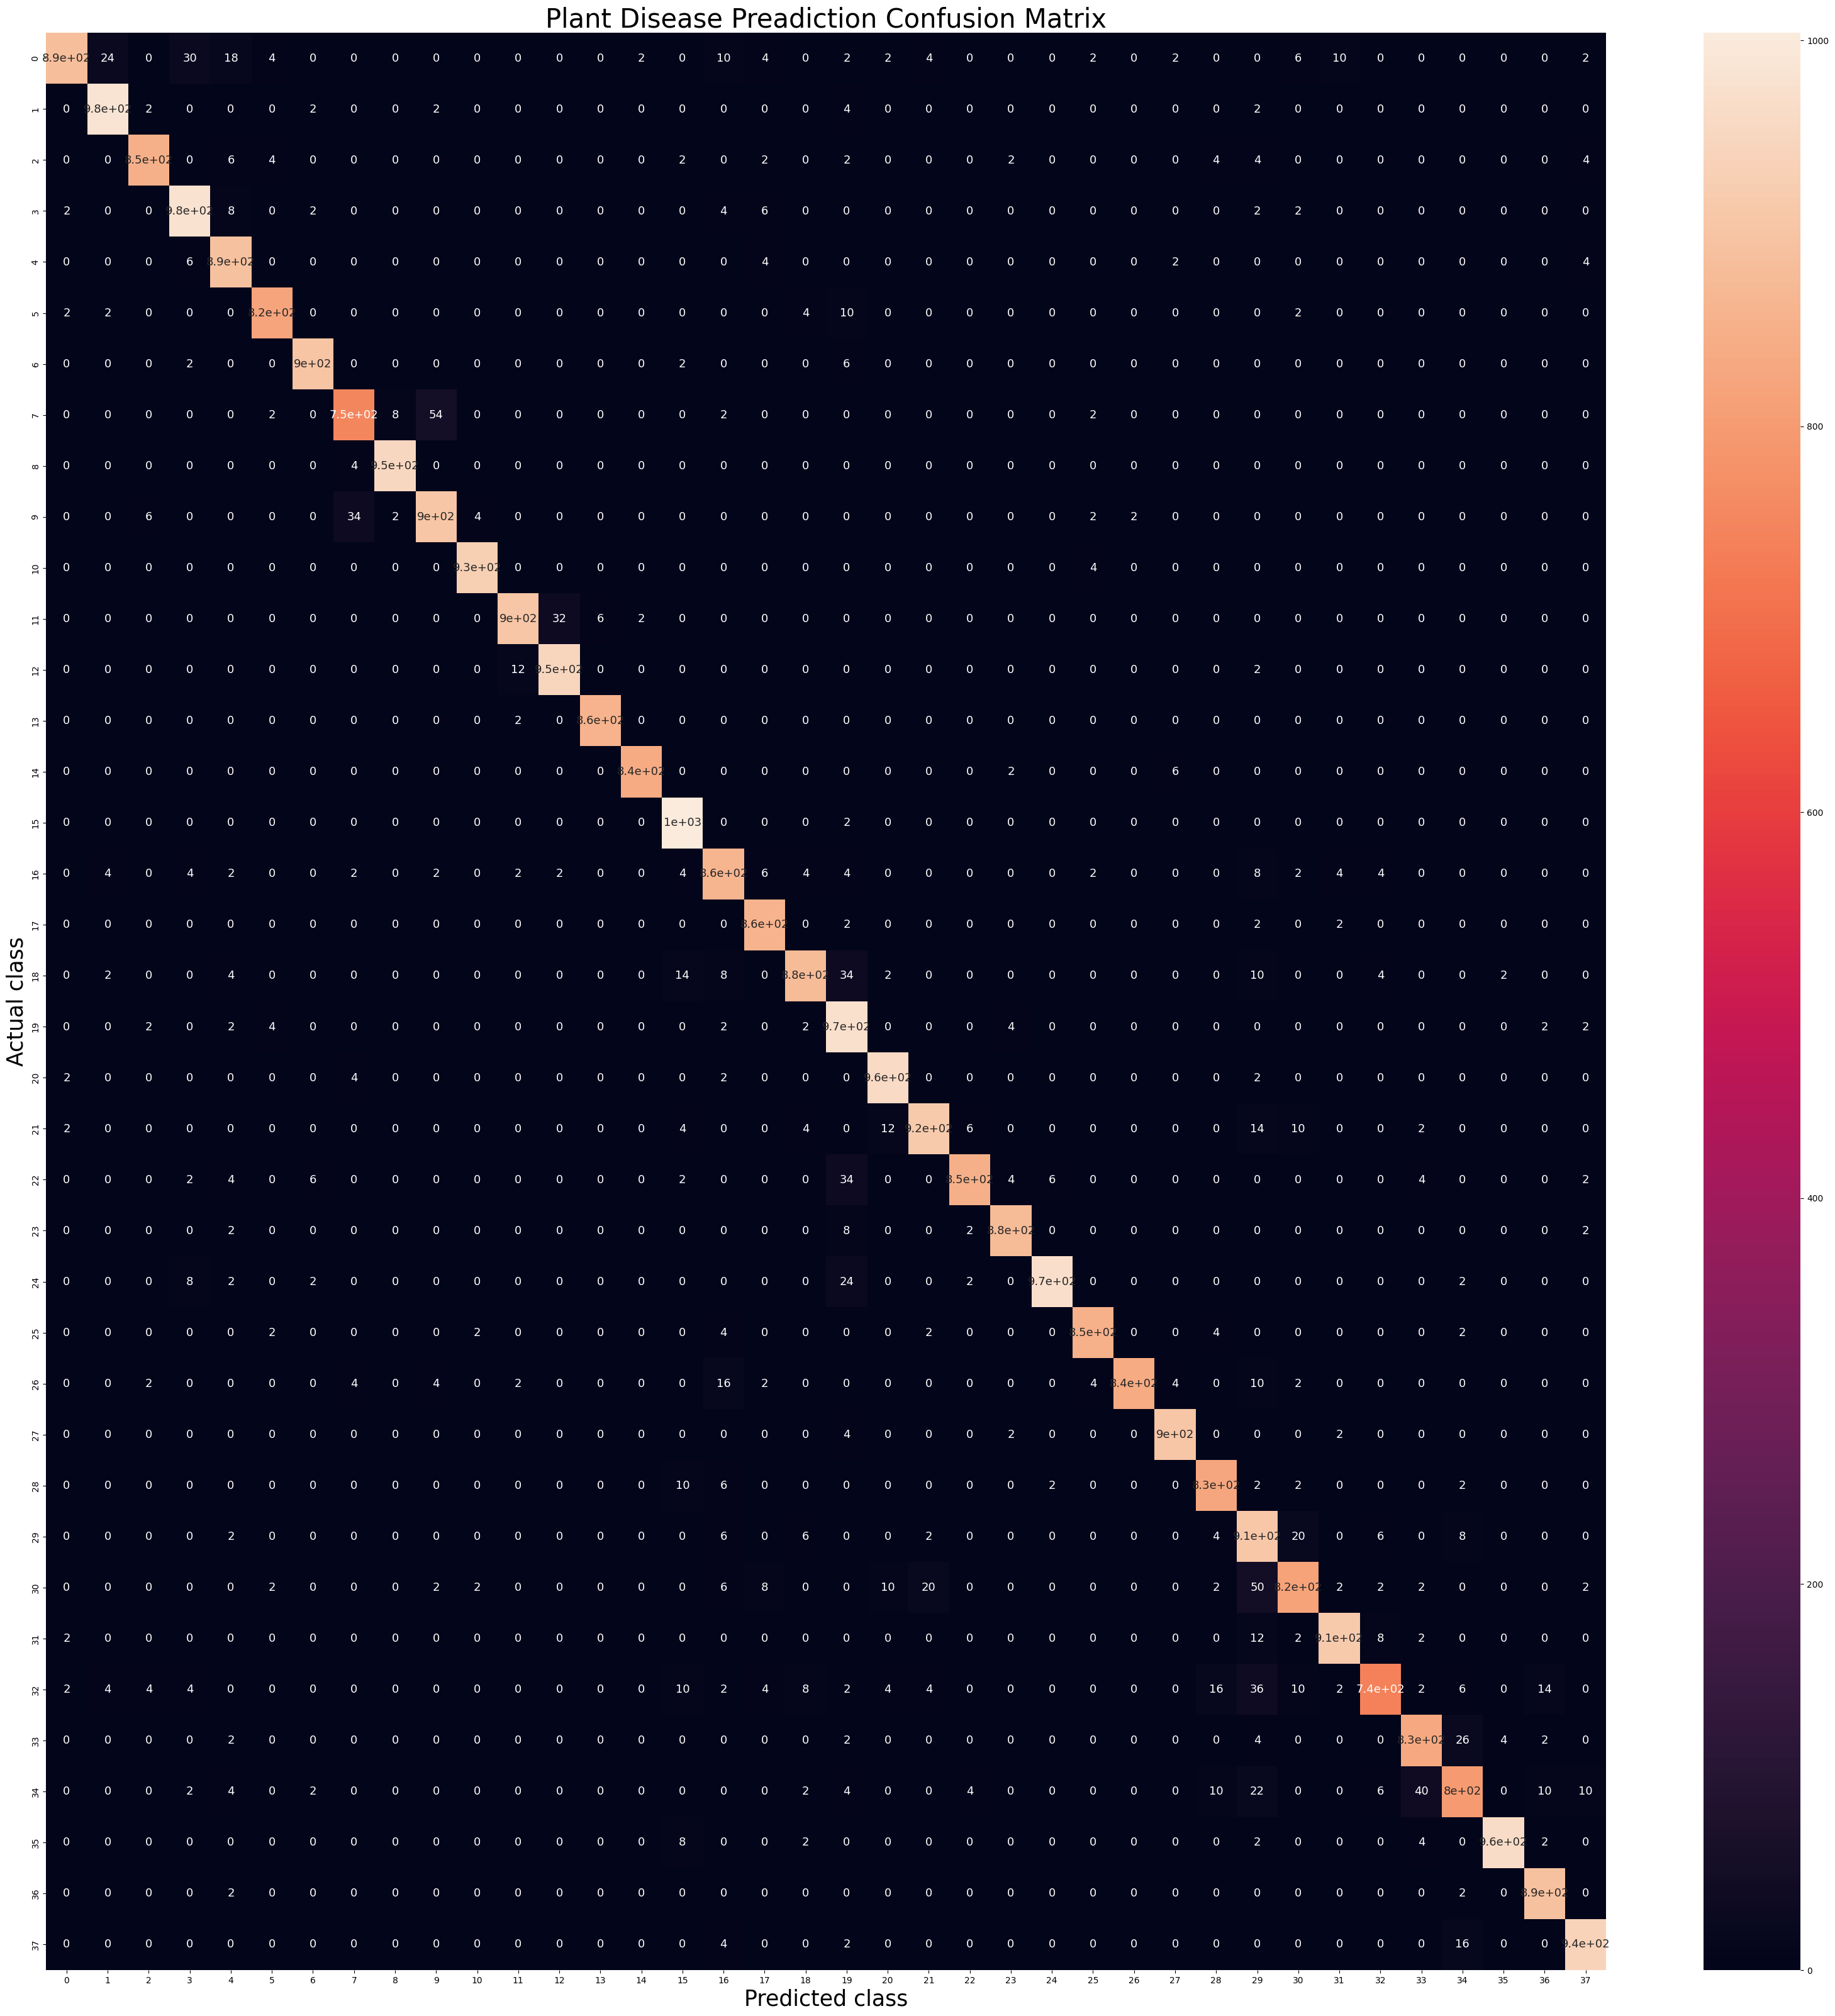

In [50]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':13})
plt.xlabel("Predicted class",fontsize=25)
plt.ylabel("Actual class",fontsize=25)
plt.title("Plant Disease Preadiction Confusion Matrix",fontsize=30)
plt.show